<a href="https://colab.research.google.com/github/iking919/Projects-in-AI-and-ML/blob/main/HW4_Task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projects in ML & AI HW4 Task 3 - Izaak King

## Part 1: Implementing Word Embeddings

### Choice of Pre-trained Embedding Model

For this assignment, I chose BERT embeddings from the Hugging Face library. BERT is a transformer-based model that generates contextual embeddings. Unlike traditional embeddings such as Word2Vec or GloVe, which produce a single static vector for each word regardless of context, BERT captures richer semantic meaning and can differentiate between different senses of the same word. Additionally, BERT naturally handles out-of-vocabulary (OOV) words by splitting them into smaller subwords, allowing it to generate embeddings for rare, compound, or new words that are not explicitly in its vocabulary. This is conceptually similar to FastText's subword approach, but BERT integrates subword information into a full transformer model, providing context-aware representations rather than just character-level approximations.

When comparing BERT to Word2Vec, a key difference lies in contextualization. Word2Vec embeddings are static, meaning a word like "bank" would have the same vector whether referring to a river bank or a financial bank. BERT, in contrast, can distinguish these meanings depending on surrounding words, making it more robust for nuanced language understanding. Compared to GloVe, which also produces static embeddings based on global co-occurrence statistics, BERT offers richer representations that are sensitive to context and can capture subtler semantic relationships. FastText does provide subword-based OOV handling, which is an advantage over Word2Vec and GloVe. However, it still produces static embeddings that do not adjust based on sentence context.

Finally, BERT is easy to integrate efficiently using the Hugging Face library, which automatically downloads pre-trained models and allows embeddings to be accessed programmatically without manual file handling. This combination of contextual embeddings, OOV handling, and ease of use makes BERT particularly suitable for this assignment, especially when compared to older embedding methods that lack one or more of these features.

### Loading BERT Embeddings Efficiently

We load BERT embeddings using the Hugging Face Transformers library.

In [1]:
from transformers import AutoTokenizer, AutoModel
import torch

# Load pre-trained BERT model and tokenizer
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

def get_word_embedding(word):
    # Tokenize word (BERT may split into subwords)
    inputs = tokenizer(word, return_tensors="pt")

    # Get hidden states
    with torch.no_grad():
        outputs = model(**inputs).last_hidden_state

    # Average embeddings of all subword tokens to get a single vector
    embedding = outputs.mean(dim=1).squeeze()
    return embedding

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Example Using Hard-Coded Inputs

To demonstrate the embeddings, we can use two hard-coded inputs, "Projects" and "datascience". This is useful for testing before allowing dynamic user input.

In [2]:
# Hard-coded test words
word1 = "Projects"
word2 = "datascience"

emb1 = get_word_embedding(word1)
emb2 = get_word_embedding(word2)

print(f"Embedding for '{word1}' (size {emb1.shape[0]}):\n", emb1)
print(f"\nEmbedding for '{word2}' (size {emb2.shape[0]}):\n", emb2)

Embedding for 'Projects' (size 768):
 tensor([ 1.8050e-01,  8.7444e-03, -2.1069e-01, -5.3521e-02, -1.4448e-04,
         3.4488e-02,  2.3112e-01, -8.3621e-02, -2.8601e-01, -1.6971e-01,
        -3.7414e-03,  1.6523e-01,  2.3708e-01,  2.2474e-01, -2.5280e-01,
        -8.7842e-02, -2.2935e-01,  4.2530e-03,  7.8759e-02,  9.6242e-02,
        -9.0149e-03,  7.4177e-02,  1.5635e-01,  1.1588e-01, -1.2424e-01,
         1.0676e-02, -1.9375e-01,  4.7637e-02, -4.6962e-01,  6.5634e-03,
        -1.4644e-01,  5.8286e-02, -1.5899e-02,  4.6954e-01,  6.5136e-02,
        -1.6060e-01, -3.6531e-02, -2.5500e-01, -2.5982e-01, -4.6986e-02,
         3.8877e-02,  5.3203e-02, -2.8449e-01, -3.6053e-01,  7.9458e-02,
        -2.2678e-01, -3.1015e-01, -8.5201e-02, -3.9892e-01,  1.3214e-01,
        -1.3287e-01,  2.8863e-01,  1.7097e-01,  5.7202e-02,  1.5249e-01,
         3.3256e-01,  2.0117e-01, -1.0530e-01,  6.4132e-02,  7.0341e-02,
         1.6595e-01,  1.3326e-01, -5.3409e-02,  8.7933e-03,  5.1528e-01,
        -2.65

Here, even though "datascience" is not explicitly in BERT's vocabulary, the tokenizer splits it into subwords like "data" and "science". The embeddings of these subwords are then averaged, approximating a vector for the full word. This demonstrates BERT's built-in OOV handling.

### Dynamic User Input for Word Embeddings

To make the program interactive, users can input any two words. The embeddings are generated similarly, and OOV words are handled automatically. We will manually input the same inputs of "Projects" and "datascience"

In [3]:
# Dynamic user input
word1 = input("Enter first word: ")
word2 = input("Enter second word: ")

emb1 = get_word_embedding(word1)
emb2 = get_word_embedding(word2)

print(f"\nEmbedding for '{word1}' (size {emb1.shape[0]}):\n", emb1)
print(f"\nEmbedding for '{word2}' (size {emb2.shape[0]}):\n", emb2)

Enter first word: Projects
Enter second word: datascience

Embedding for 'Projects' (size 768):
 tensor([ 1.8050e-01,  8.7444e-03, -2.1069e-01, -5.3521e-02, -1.4448e-04,
         3.4488e-02,  2.3112e-01, -8.3621e-02, -2.8601e-01, -1.6971e-01,
        -3.7414e-03,  1.6523e-01,  2.3708e-01,  2.2474e-01, -2.5280e-01,
        -8.7842e-02, -2.2935e-01,  4.2530e-03,  7.8759e-02,  9.6242e-02,
        -9.0149e-03,  7.4177e-02,  1.5635e-01,  1.1588e-01, -1.2424e-01,
         1.0676e-02, -1.9375e-01,  4.7637e-02, -4.6962e-01,  6.5634e-03,
        -1.4644e-01,  5.8286e-02, -1.5899e-02,  4.6954e-01,  6.5136e-02,
        -1.6060e-01, -3.6531e-02, -2.5500e-01, -2.5982e-01, -4.6986e-02,
         3.8877e-02,  5.3203e-02, -2.8449e-01, -3.6053e-01,  7.9458e-02,
        -2.2678e-01, -3.1015e-01, -8.5201e-02, -3.9892e-01,  1.3214e-01,
        -1.3287e-01,  2.8863e-01,  1.7097e-01,  5.7202e-02,  1.5249e-01,
         3.3256e-01,  2.0117e-01, -1.0530e-01,  6.4132e-02,  7.0341e-02,
         1.6595e-01,  1.332

### Handling OOV Words and Approximation

BERT's subword tokenization provides a robust method for handling words that are not present in the model's vocabulary. When BERT encounters an unfamiliar word, it automatically splits it into smaller subword units. For instance, a compound or newly coined word like "datascience" might be tokenized into "data" and "##science". By averaging the embeddings of these subwords, BERT can produce an approximate vector that represents the meaning of the full word, even though the word itself was never seen during training. This mechanism allows the model to gracefully handle rare or novel words without producing errors or missing embeddings.

In addition to subword averaging, there are other strategies for approximating embeddings of out-of-vocabulary words. One approach is to average the embeddings of semantically similar words that are already known to the model. Another option is to leverage character-level or subword models, such as FastText, which can generate embeddings from the internal structure of words. Finally, contextual embeddings provide a powerful tool. By embedding the word within surrounding text, BERT can refine the representation based on context, producing a more accurate and semantically meaningful vector.

Overall, these strategies ensure that all word, whether common, rare, or new, can be embedded effectively, making BERT a flexible and reliable choice for a wide range of natural language processing tasks.

## Part 2: Cosine Similarity Computation

### Cosine Similarity Implementation

To measure semantic similarity between words in embedding space, cosine similarity was implemented between two embeddings generated by BERT. These word embeddings are 768-dimensional dense vectors that encode semantic meaning through both direction and magnitude. However, in high-dimensional spaces, the magnitude of a vector is typically less important than its orientation. Cosine similarity computes the cosine of the angle between two vectors, effectively measuring how aligned they are regardless of scale. A cosine similarity score of 1 indicates that two words are highly similar, 0 indicates no semantic relationship, and -1 suggests opposite meanings. This metric is widely used in natural language processing because it remains stable in high-dimensional spaces and emphasizes semantic direction rather than vector length.

In [4]:
import torch
import torch.nn.functional as F

def cosine_similarity(emb1, emb2):
    # Compute cosine similarity between two embeddings.
    return F.cosine_similarity(emb1.unsqueeze(0), emb2.unsqueeze(0)).item()

### Why Cosine Similarity Is Useful in Word Embedding Space

Cosine similarity is particularly useful in word embedding space because embeddings are high-dimensional vectors where semantic meaning is primarily encoded in vector direction rather than magnitude. In many embedding models, vector lengths can vary due to training dynamics, but words with similar meanings tend to point in similar directions. By measuring the angle between vectors instead of their absolute distance, cosine similarity provides a normalized and scale-invariant measure of relatedness. This makes it especially effective for comparing semantic similarity, clustering words, and performing tasks such as information retrieval and recommendation systems.

## Batch Processing of Word Pairs

In practical NLP applications, systems often compare many word pairs simultaneously, such as in semantic search or clustering tasks. To simulate this real-world usage, we implemented batch processing that allows users to input multiple word pairs and compute their similarities in a single run. For each pair, embeddings are generated using the previously defined BERT function, and cosine similarity is calculated. The results are then stored and printed in an organized format.

We test the implementation with pairs of

  (Apple, Orange)
  (Bride, Groom)
  (Automobile, Human)
  (Cat, Cellphone)

In [5]:
def compute_batch_similarity(word_pairs):
    # Compute cosine similarity for multiple word pairs
    results = []

    for w1, w2 in word_pairs:
        emb1 = get_word_embedding(w1)
        emb2 = get_word_embedding(w2)
        sim = cosine_similarity(emb1, emb2)
        results.append((w1, w2, sim))

    return results


# Usage Examples
word_pairs = [
    ("Apple", "Orange"),
    ("Bride", "Groom"),
    ("Automobile", "Human"),
    ("Cat", "Cellphone")
]

results = compute_batch_similarity(word_pairs)

for w1, w2, sim in results:
    print(f"Cosine similarity between '{w1}' and '{w2}': {sim:.4f}")

Cosine similarity between 'Apple' and 'Orange': 0.8710
Cosine similarity between 'Bride' and 'Groom': 0.8809
Cosine similarity between 'Automobile' and 'Human': 0.7861
Cosine similarity between 'Cat' and 'Cellphone': 0.6343


The cosine similarity results show that semantically related word pairs such as “Apple” and “Orange” (0.8710) and “Bride” and “Groom” (0.8809) receive high similarity scores, indicating that their embeddings are closely aligned in vector space. In contrast, less related pairs such as “Automobile” and “Human” (0.7861) and “Cat” and “Cellphone” (0.6343) produce lower similarity values, reflecting weaker semantic relationships. However, even unrelated words still yield moderately high scores, which is characteristic of contextual embeddings generated by BERT, where the embedding space tends to be dense and similarity values are generally compressed within a higher numerical range.

### Visualization of Word Embeddings Using PCA

Word embeddings exist in a 768-dimensional space, which cannot be directly visualized. To interpret semantic relationships visually, dimensionality reduction techniques are required. Principal Component Analysis (PCA) was used to reduce the high-dimensional embeddings to two dimensions while preserving as much variance as possible. PCA projects the embeddings onto the directions of greatest variance, enabling visualization in a 2D scatter plot.

This visualization allows us to observe clustering behavior. Words that are semantically similar (such as "Apple" and "Orange) should appear closer together, while unrelated words (such as “car” and “banana”) should appear farther apart. This provides an intuitive geometric interpretation of semantic similarity.

/tmp/ipykernel_11032/1854896998.py:12: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  embeddings = torch.tensor(embeddings)


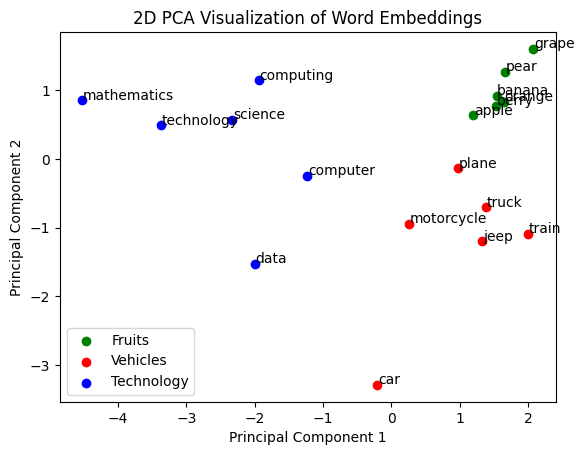

In [6]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import torch

def visualize_embeddings(words):
    embeddings = []

    for word in words:
        emb = get_word_embedding(word)
        embeddings.append(emb.numpy())

    embeddings = torch.tensor(embeddings)

    # Reduce dimensions
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(embeddings)

    plt.figure()

    # Define category boundaries
    fruits = words[:6]
    vehicles = words[6:12]
    tech = words[12:]

    # Plot fruits (green)
    for i, word in enumerate(fruits):
        x, y = reduced[i]
        plt.scatter(x, y, color="green")
        plt.text(x + 0.01, y + 0.01, word)

    # Plot vehicles (red)
    for i, word in enumerate(vehicles, start=6):
        x, y = reduced[i]
        plt.scatter(x, y, color="red")
        plt.text(x + 0.01, y + 0.01, word)

    # Plot tech terms (blue)
    for i, word in enumerate(tech, start=12):
        x, y = reduced[i]
        plt.scatter(x, y, color="blue")
        plt.text(x + 0.01, y + 0.01, word)

    plt.title("2D PCA Visualization of Word Embeddings")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")

    # Optional legend
    plt.scatter([], [], color="green", label="Fruits")
    plt.scatter([], [], color="red", label="Vehicles")
    plt.scatter([], [], color="blue", label="Technology")
    plt.legend()

    plt.show()


words_to_visualize = [
    "apple", "orange", "banana", "grape", "berry", "pear",
    "car", "truck", "motorcycle", "jeep", "plane", "train",
    "data", "science", "computer", "computing", "mathematics", "technology"
]

visualize_embeddings(words_to_visualize)

From this plot we can see the general grouping of Fruits, Vehicles and Technology terms were separated, with the fruit clustered tightly together and the technology more spread out. Overall, from our PCA representation, we see the Cosine Similarity does a good job at separating our words with similar meanings.

# Part 3: Designing a Novel Dissimilarity Metric

## Custom Dissimilarity Metric: Euclidean Distance

To move beyond cosine similarity, Euclidean distance was implemented as a dissimilarity metric. While cosine similarity measures the angular alignment between two word embeddings, it does not account for the spatial separation between vectors. Euclidean distance measures the straight-line distance between two points in high-dimensional space. Formally, for two embeddings $v_1$ and $v_2$, Euclidean distance is defined as:

<br>

$D(v_1, v_2) = \|| v_1 - v_2 \||_2$

<br>



This metric captures how far apart two words are in embedding space. Larger values indicate greater distance/divergence, while smaller values indicate closer proximity. Unlike cosine similarity, which only considers vector direction, Euclidean distance reflects overall positional separation. As a result, it can better capture novelty or diversity between words whose vectors may point in similar directions but differ substantially in magnitude or location.

## Implementation with Metric Toggle

To allow flexibility, the system was designed so users can toggle between cosine similarity and Euclidean distance using a function parameter.

In [7]:
import torch
import torch.nn.functional as F

def cosine_similarity(emb1, emb2):
    return F.cosine_similarity(emb1.unsqueeze(0), emb2.unsqueeze(0)).item()

def euclidean_distance(emb1, emb2):
    return torch.norm(emb1 - emb2, p=2).item()

def compute_metric(word1, word2, metric="cosine"):
    emb1 = get_word_embedding(word1)
    emb2 = get_word_embedding(word2)

    if metric == "cosine":
        return cosine_similarity(emb1, emb2)
    elif metric == "euclidean":
        return euclidean_distance(emb1, emb2)
    else:
        raise ValueError("Metric must be 'cosine' or 'euclidean'")

## Ranking Words by Similarity or Dissimilarity

To analyze how different metrics affect word relationships, a ranking function was implemented. This function ranks words relative to a target word using the selected metric.

**It's important to note that a smaller score for Euclidean metric indicates that the two words are more closely aligned. Meanwhile, a score closer to 1 for Cosine metric indicates the words are more closely aligned.**

In [8]:
def rank_words(target_word, word_list, metric="cosine"):
    target_emb = get_word_embedding(target_word)
    scores = []

    for word in word_list:
        emb = get_word_embedding(word)

        score = compute_metric(target_word, word, metric)

        scores.append((word, score))

    # Sorting logic
    if metric == "cosine":
        scores.sort(key=lambda x: x[1], reverse=True)  # Higher = more similar
    else:
        scores.sort(key=lambda x: x[1])  # Lower = more similar (closer)

    return scores

To test these rankings, we look at how "cat" ranks against "dog", "lion" and "table" using both Cosine and Euclidean metrics.

In [9]:
# Example ranking for cosine
words = ["dog", "lion", "table", "tiger"]
ranking = rank_words("cat", words, metric="cosine")

for word, score in ranking:
      print(word, score)

tiger 0.9125476479530334
lion 0.9089463949203491
dog 0.9008513689041138
table 0.7778878808021545


In [10]:
# Example ranking for Euclidean
words = ["dog", "lion", "table", "tiger"]
ranking = rank_words("cat", words, metric="euclidean")

for word, score in ranking:
      print(word, score)

tiger 3.5638558864593506
lion 3.5758841037750244
dog 3.7157890796661377
table 5.622091770172119


This demonstrates how Euclidean and Cosine metrics produces a similar ranking, though Euclidean distance seems to show a greater variation between "cat" and "table". This highlights how spatial separation influences perceived semantic closeness.

## Visualization: Ranking Plot

To visualize ranking differences, a bar plot was generated showing similarity or dissimilarity scores relative to a target word.

We will once again look at how "cat" ranks against "dog", "lion" and "table" using both Cosine and Euclidean metrics.

**Once again note that the score closer to 1 indicate similarity for Cosine metric, while smaller score indicates similarity for Euclidean Metric.**

### Cosine Rankings

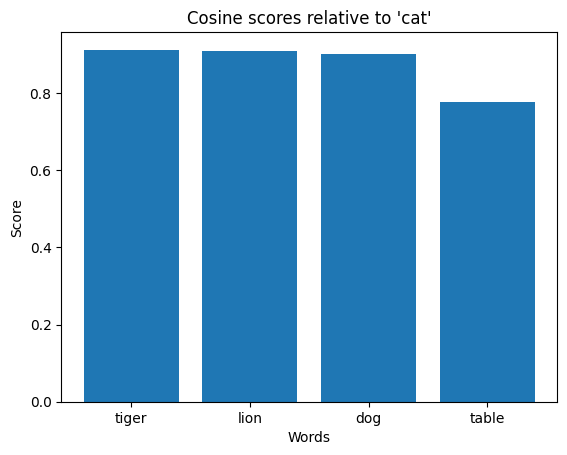

In [11]:
import matplotlib.pyplot as plt

def plot_ranking(target_word, word_list, metric="cosine"):
    rankings = rank_words(target_word, word_list, metric)

    words = [w for w, _ in rankings]
    scores = [s for _, s in rankings]

    plt.figure()
    plt.bar(words, scores)
    plt.title(f"{metric.capitalize()} scores relative to '{target_word}'")
    plt.xlabel("Words")
    plt.ylabel("Score")
    plt.show()


plot_ranking("cat", ["dog", "lion", "table", "tiger"], metric="cosine")

### Euclidean Distance Rankings

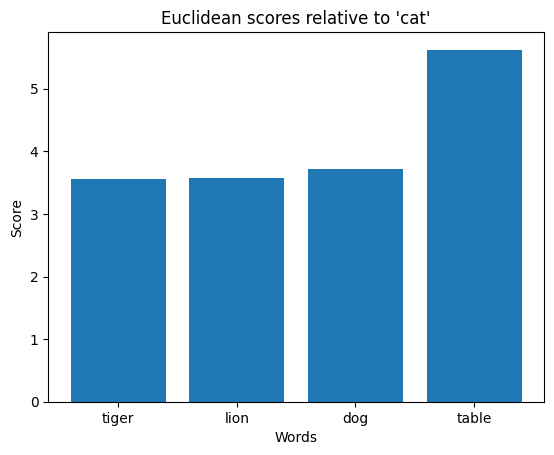

In [12]:
import matplotlib.pyplot as plt

def plot_ranking(target_word, word_list, metric="cosine"):
    rankings = rank_words(target_word, word_list, metric)

    words = [w for w, _ in rankings]
    scores = [s for _, s in rankings]

    plt.figure()
    plt.bar(words, scores)
    plt.title(f"{metric.capitalize()} scores relative to '{target_word}'")
    plt.xlabel("Words")
    plt.ylabel("Score")
    plt.show()


plot_ranking("cat", ["dog", "lion", "table", "tiger"], metric="euclidean")

### Additional Ranking Example: Science
To further test the metrics, we examine abstract concepts by ranking words relative to "science". This ensures the metric performs well on other concepts, not just the prior animals.

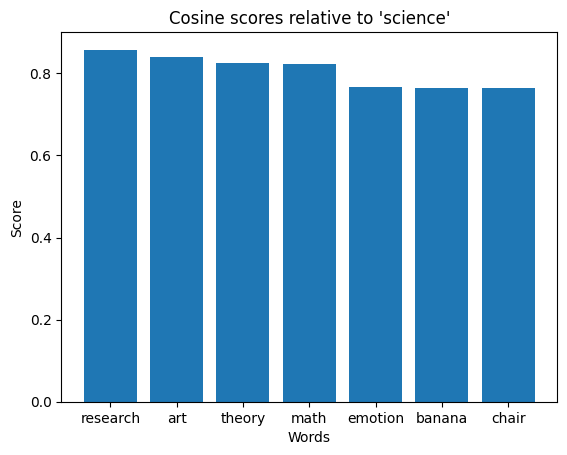

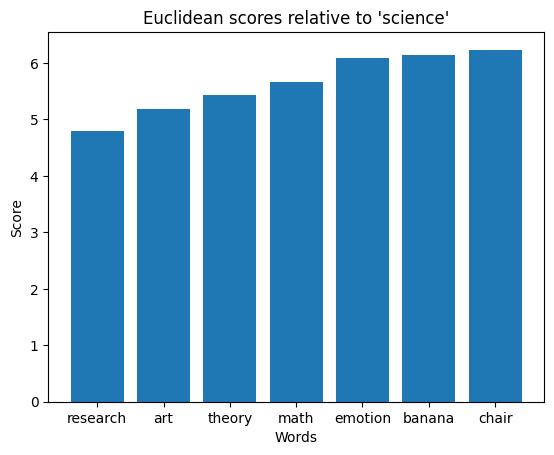

In [13]:
# Ranking abstract words relative to 'science'
target = "science"

words = [
    "research",
    "math",
    "theory",
    "art",
    "emotion",
    "banana",
    "chair"
]

plot_ranking(target, words, metric="cosine")
plot_ranking(target, words, metric="euclidean")

Once again the metrics perform similar across all words, with Euclidean scores showing a higher variance in similarities.

## Heatmap Comparison Across Multiple Words

To compare relationships across multiple word pairs, a heatmap was created. This allows visual comparison of similarity and dissimilarity patterns.

In [14]:
import seaborn as sns
import numpy as np

def metric_heatmap(words, metric="cosine"):
    matrix = []

    for w1 in words:
        row = []
        for w2 in words:
            score = compute_metric(w1, w2, metric)
            row.append(score)
        matrix.append(row)

    matrix = np.array(matrix)

    plt.figure()
    sns.heatmap(matrix, xticklabels=words, yticklabels=words, annot=True)
    plt.title(f"{metric.capitalize()} Heatmap")
    plt.show()

We begin our heatmap comparison using the same subset of "cat", "dog", "lion", "tiger", and "table"

### Cosine Heatmap

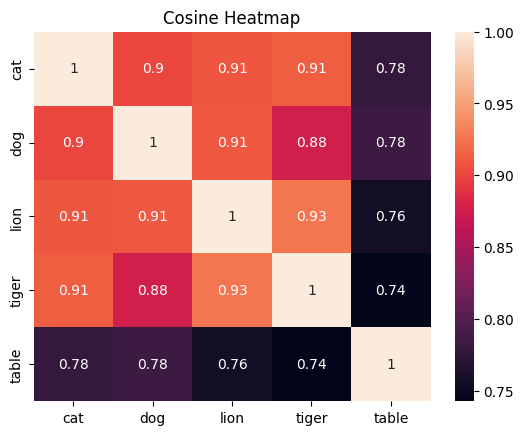

In [15]:
words = ["cat", "dog", "lion", "tiger", "table"]
metric_heatmap(words, metric="cosine")

### Euclidean Heatmap

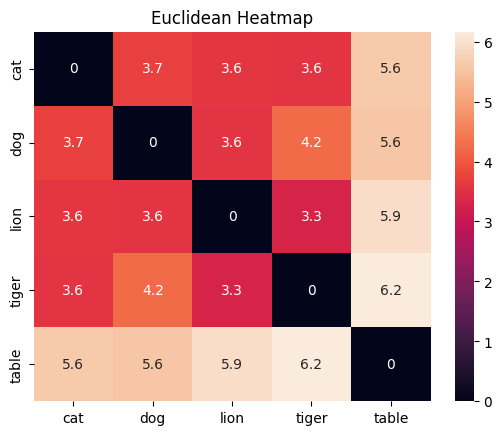

In [16]:
words = ["cat", "dog", "lion", "tiger", "table"]
metric_heatmap(words, metric="euclidean")

### Additional heatmap Example

We create further heatmap examples using the prior "science" subset of words

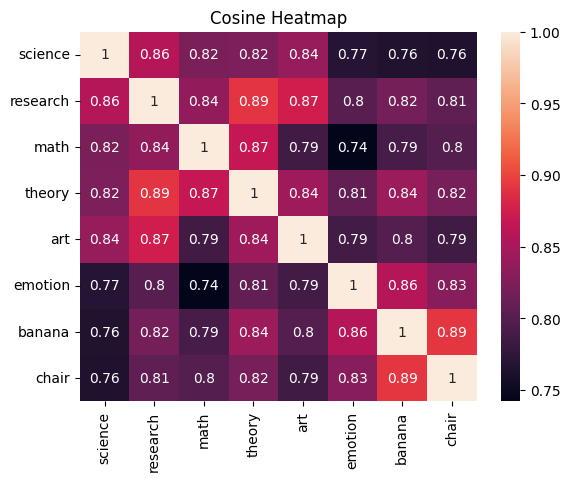

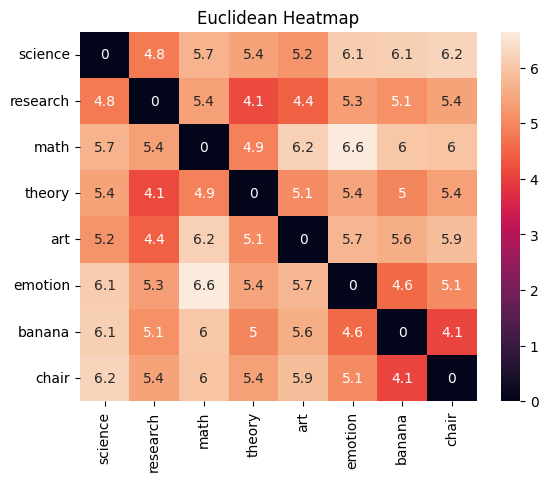

In [17]:
# Using additional set of words
words = [
    "science",
    "research",
    "math",
    "theory",
    "art",
    "emotion",
    "banana",
    "chair"
]

metric_heatmap(words, metric="cosine")
metric_heatmap(words, metric="euclidean")

Overall, Euclidean distance was introduced as a dissimilarity metric to complement cosine similarity when comparing word embeddings generated by BERT. Both metrics produced broadly consistent ranking patterns, with semantically related words appearing closer to the target word and unrelated words ranking farther away. However, Euclidean distance exhibited a greater variance in score values, resulting in a wider numerical spread between closely related and unrelated terms. This increased variance can provide a clearer quantitative distinction between levels of semantic similarity, potentially offering a more sensitive indication of novelty or diversity in embedding space. While cosine similarity remains effective for measuring directional alignment, Euclidean distance adds an additional geometric perspective by capturing absolute spatial separation. Together, the comparison demonstrates that although both metrics perform similarly in identifying general semantic structure, Euclidean distance may better highlight fine-grained differences in word relationships.